# Pytorch Interview   
https://github.com/Devinterview-io/pytorch-interview-questions 

In [1]:
import numpy as np 
from typing import List, Optional


class KMeans:
    def kmeans(self, n_clusters: int, samples: List[List[float]]):
        centroids = samples[np.random.choice(len(samples), n_clusters, replace=False)]
        def assign_labels(samples, centroids):
            labels = []
            for sample in samples:
                distances = np.linalg.norm(sample - centroids, axis=1)
                labels.append(np.argmin(distances))
            return labels 
        def compute_centroids(samples, labels, n_clusters, prev_centroids):
            centroids = np.copy(prev_centroids)
            for i in range(n_clusters):
                samples_in_cluster = samples[np.where(np.array(labels) == i)]
                if len(samples_in_cluster) > 0:
                    centroids[i] = np.mean(samples_in_cluster, axis=0)
            return centroids

        while True:
            labels = assign_labels(samples, centroids)
            new_centroids = compute_centroids(samples, labels, n_clusters, centroids)
            if np.array_equal(centroids, new_centroids):
                break
            centroids = new_centroids
        return labels, centroids

In [2]:
import numpy as np 
from typing import List

class KMeans:
    def kmeans(self, n_clusters: int, samples: List[List[float]]):
        centroids = samples[np.random.choice(len(samples), n_clusters, replace=False)]
        while True:
            def assign_labels(samples, centroids):
                labels = []
                for sample in samples:
                    distances = np.linalg.norm(sample - centroids, axis = 1)
                    labels.append(np.argmin(distances))
                return labels
            labels = assign_labels(samples, centroids)
            
            def compute_centroids(samples, labels, n_clusters):
                centroids = []
                for i in range(n_clusters):
                    samples_in_cluster = samples[np.where(np.array(labels) == i)]
                    centroids.append(np.mean(samples_in_cluster, axis=0))
                return centroids
            new_centroids = np.array(compute_centroids(samples, labels, n_clusters))
            
            if np.array_equal(centroids, new_centroids):
                break
            
            centroids = new_centroids
        return labels, centroids


In [3]:
print(KMeans().kmeans(2, np.array([[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]])))

([1, 1, 1, 0, 0, 0], array([[4., 2.],
       [1., 2.]]))


In [4]:
print(KMeans().kmeans(2, np.array([[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]])))
# [0, 0, 0, 1, 1, 1]

([0, 0, 1, 0, 0, 1], array([[2.5, 3. ],
       [2.5, 0. ]]))


### K-means

In [5]:
import numpy as np 

class KMeans:
    def __init__(self, clusters, max_iter=None) -> None:
        self.clusters = clusters 
        self.max_iter = max_iter
        self.centroids = None

    def _label_samples(self, samples, centroids):
        labels = []
        for sample in samples:
            # Attention: linalg, axis = 1
            distances = np.linalg.norm(sample - centroids, axis=1)
            labels.append(np.argmin(distances))
        return labels

    def _compute_centroids(self, samples, labels):
        # Attention: np.copy
        centroids = np.copy(self.centroids)
        for i in range(self.clusters):
            # Attention: np.where
            samples_in_cluster = samples[np.where(np.array(labels) == i)]
            # Attention: not empty element
            if len(samples_in_cluster) > 0:
                centroids[i] = np.mean(samples_in_cluster, axis=0)
        return centroids

    def fit(self, samples):
        self.centroids = samples[np.random.choice(range(len(samples)), self.clusters, replace=False)]
        iter = 0
        while True:
            if self.max_iter and iter >= self.max_iter:
                break 
            labels = self._label_samples(samples, self.centroids)
            new_centroids = self._compute_centroids(samples, labels)
            # Attention: break criteria
            if np.array_equal(self.centroids, new_centroids):
                break
            self.centroids = new_centroids
        return labels, self.centroids
    
    def predict(self, samples):
        labels = self._label_samples(samples, self.centroids)
        return labels

In [6]:
x1 = np.random.randn(5,2) + 5
x2 = np.random.randn(5,2) - 5
X = np.concatenate([x1,x2], axis=0)
k = 2

# Initialize the KMeans object with k=3
kmeans = KMeans(2)

# Fit the k-means model to the dataset
kmeans.fit(X)

# Get the cluster assignments for the input dataset
cluster_assignments = kmeans.predict(X)

# Print the cluster assignments
print(cluster_assignments)

# Print the learned centroids
print(kmeans.centroids)

[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
[[-4.74672748 -4.8774915 ]
 [ 5.27981959  5.35699767]]


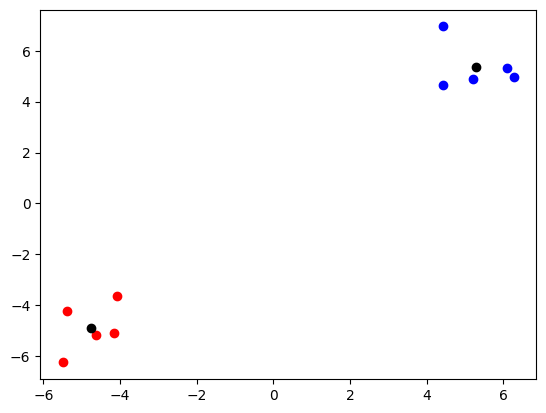

In [7]:
from matplotlib import pyplot as plt
# Plot the data points with different colors based on their cluster assignments
colors = ['r', 'b']
for i in range(kmeans.clusters):
    plt.scatter(X[np.where(np.array(cluster_assignments) == i)][:,0], 
                X[np.where(np.array(cluster_assignments) == i)][:,1], 
                color=colors[i])

# Plot the centroids as black circles
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], color='black', marker='o')

# Show the plot
plt.show()

In [8]:
import numpy as np

class KMeans:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
    
    def fit(self, X):
        # Initialize centroids randomly
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False)]
        
        # Iterate until convergence or maximum number of iterations is reached
        for i in range(self.max_iters):
            # Assign each data point to the closest centroid
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            cluster_assignments = np.argmin(distances, axis=1)
            
            # Update the centroids based on the new cluster assignments
            new_centroids = np.array([np.mean(X[np.where(cluster_assignments == j)], axis=0) 
                                      for j in range(self.k)])
            
            # Check for convergence
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
                
            self.centroids = new_centroids
    
    def predict(self, X):
        # Assign each data point to the closest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)
        
        return cluster_assignments

In [9]:
x1 = np.random.randn(5,2) + 5
x2 = np.random.randn(5,2) - 5
X = np.concatenate([x1,x2], axis=0)

# Initialize the KMeans object with k=3
kmeans = KMeans(k=2)

# Fit the k-means model to the dataset
kmeans.fit(X)

# Get the cluster assignments for the input dataset
cluster_assignments = kmeans.predict(X)

# Print the cluster assignments
print(cluster_assignments)

# Print the learned centroids
print(kmeans.centroids)

[1 1 1 1 1 0 0 0 0 0]
[[-4.66903283 -4.66872517]
 [ 5.01079204  5.41164942]]


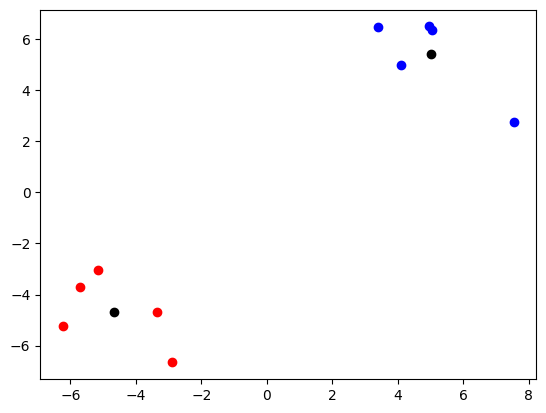

In [10]:
from matplotlib import pyplot as plt
# Plot the data points with different colors based on their cluster assignments
colors = ['r', 'b']
for i in range(kmeans.k):
    plt.scatter(X[np.where(np.array(cluster_assignments) == i)][:,0], 
                X[np.where(np.array(cluster_assignments) == i)][:,1], 
                color=colors[i])

# Plot the centroids as black circles
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], color='black', marker='o')

# Show the plot
plt.show()

In [12]:
import numpy as np

class KMeans:
    def __init__(self, cluster=2, max_iter=100):
        self.cluster = cluster
        self.max_iter = max_iter
        self.centroids = None

    def _assign_samples(self, samples):
        # Compute distances from each sample to each centroid
        distances = np.linalg.norm(samples[:, np.newaxis] - self.centroids, axis=2)
        # Assign each sample to the closest centroid
        labels = np.argmin(distances, axis=1)
        return labels

    def _compute_centroids(self, samples, labels):
        new_centroids = np.zeros((self.cluster, samples.shape[1]))
        for i in range(self.cluster):
            cluster_samples = samples[labels == i]
            if len(cluster_samples) > 0:
                new_centroids[i] = np.mean(cluster_samples, axis=0)
            else:
                # If a cluster gets no samples, reinitialize its centroid randomly
                new_centroids[i] = samples[np.random.choice(len(samples))]
        return new_centroids

    def fit(self, samples):
        # Randomly initialize centroids
        indices = np.random.choice(len(samples), self.cluster, replace=False)
        self.centroids = samples[indices]
        for _ in range(self.max_iter):
            labels = self._assign_samples(samples)
            new_centroids = self._compute_centroids(samples, labels)
            if np.allclose(new_centroids, self.centroids):
                break
            self.centroids = new_centroids
        return labels, self.centroids

    def predict(self, samples):
        return self._assign_samples(samples)


[1 1 1 1 1 0 0 0 0 0]
[[-5.05712451 -4.8297977 ]
 [ 5.13784422  5.67503969]]


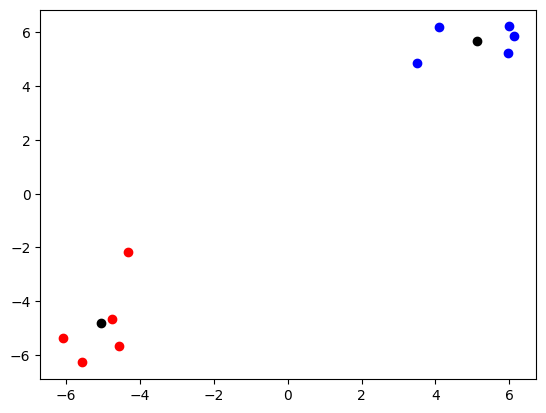

In [13]:
x1 = np.random.randn(5,2) + 5
x2 = np.random.randn(5,2) - 5
X = np.concatenate([x1, x2], axis=0)

# Initialize the KMeans object with k=3
kmeans = KMeans(cluster=2)

# Fit the k-means model to the dataset
kmeans.fit(X)

# Get the cluster assignments for the input dataset
cluster_assignments = kmeans.predict(X)

# Print the cluster assignments
print(cluster_assignments)

# Print the learned centroids
print(kmeans.centroids)
from matplotlib import pyplot as plt
# Plot the data points with different colors based on their cluster assignments
colors = ['r', 'b']
for i in range(kmeans.cluster):
    plt.scatter(X[np.where(np.array(cluster_assignments) == i)][:,0], 
                X[np.where(np.array(cluster_assignments) == i)][:,1], 
                color=colors[i])

# Plot the centroids as black circles
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], color='black', marker='o')

# Show the plot
plt.show()